# Introduction

In this notebook, we’ll explore how to train a lightweight NanoGPT on the Tiny Stories dataset. NanoGPT, developed by Andrej Karpathy, is a simplified variant of GPT designed for simplicity and speed. Our goal is to generate creative and coherent text based on the input data. I will also use Wandb library to track the experiments on the model.

# Import Libraries

In [1]:
# Clone the NanoGPT
!git clone https://github.com/karpathy/nanoGPT.git
# install tiktoken
!pip install tiktoken

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 9.11 MiB/s, done.
Resolving deltas: 100% (382/382), done.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import nanoGPT.model as GPT
import wandb
import os

In [3]:
from kaggle_secrets import UserSecretsClient
# Load API keys https://www.kaggle.com/discussions/product-feedback/114053
secret_label = "WANDB_API_KEY" 
my_secret = UserSecretsClient().get_secret(secret_label)
wandb.login(key=my_secret)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alawdisoft (alawdi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
class GPTConfig: # Model config from NanoGPT
    block_size: int = 1024
    vocab_size: int = 50304 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster

config = GPTConfig

In [5]:
wandb_config = {k:v for k,v in vars(config).items() if not callable(getattr(config, k)) and not k.startswith("__")} # Creating Wandb hyperparameters config for tracking experiements
wandb_config

{'block_size': 1024,
 'vocab_size': 50304,
 'n_layer': 12,
 'n_head': 12,
 'n_embd': 768,
 'dropout': 0.0,
 'bias': True}

In [6]:
import os
import wandb
wandb.login()

wandb.init(project="nanogpt-tinystories", name="nanoGPT", config=wandb_config)

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260420_042215-h6s8i6p7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run nanoGPT
wandb: ⭐️ View project at https://wandb.ai/alawdi/nanogpt-tinystories
wandb: 🚀 View run at https://wandb.ai/alawdi/nanogpt-tinystories/runs/h6s8i6p7


# Tiny Stories datasets and preprocessing

TinyStories, a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We show that TinyStories can be used to train and evaluate LMs that are much smaller than the state-of-the-art models (below 10 million total parameters)

In [7]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [8]:
import tiktoken
import os

enc = tiktoken.get_encoding("gpt2") # dictionry

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"): 
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

# Training

In [9]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

In [10]:
# Training Config

learning_rate = 1e-3 
max_iters = 6000
warmup_steps = 100
min_lr = 5e-5
eval_iters = 100
batch_size = 6 
block_size = 1024

gradient_accumulation_steps = 20

device =  "cuda" if torch.cuda.is_available() else "cpu" 
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [11]:
# !pip uninstall torch torchvision torchaudio -y
# !pip install --pre --upgrade --no-cache-dir torch --extra-index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install --pre --upgrade --no-cache-dir torchvision --extra-index-url https://download.pytorch.org/whl/nightly/cu128


In [12]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

nanoGPT = GPT.GPT(config)
optimizer =  torch.optim.AdamW(nanoGPT.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

number of parameters: 123.69M


/tmp/ipykernel_23/2917886634.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [13]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

for epoch in tqdm(range(max_iters)):
    if epoch%eval_iters == 0 and epoch != 0:
        losses = estimate_loss(nanoGPT)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.4f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]
        
        wandb.log({
                "epoch": epoch,
                "train/loss": losses['train'],
                "val/loss": losses['val'],
                "lr": optimizer.param_groups[0]['lr']
            })
        
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(nanoGPT.state_dict(), best_model_params_path)
    
    X,y = get_batch("train")
    
    with ctx:
        logits, loss = nanoGPT(X, y)
        loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
        scaler.scale(loss).backward()
        
    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(nanoGPT.parameters(), 1)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)        
    scheduler.step()    
    
    
wandb.finish()

  0%|          | 0/6000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 100: train loss 6.8767, val loss 6.8897
The current learning rate: 0.0010
Epoch 200: train loss 5.9531, val loss 5.9397
The current learning rate: 0.0010
Epoch 300: train loss 5.7398, val loss 5.7448
The current learning rate: 0.0010
Epoch 400: train loss 5.6602, val loss 5.6754
The current learning rate: 0.0010
Epoch 500: train loss 5.6428, val loss 5.6554
The current learning rate: 0.0010
Epoch 600: train loss 5.6063, val loss 5.6014
The current learning rate: 0.0010
Epoch 700: train loss 5.5771, val loss 5.5979
The current learning rate: 0.0010
Epoch 800: train loss 5.5145, val loss 5.5276
The current learning rate: 0.0010
Epoch 900: train loss 5.4840, val loss 5.4789
The current learning rate: 0.0010
Epoch 1000: train loss 5.3619, val loss 5.3689
The current learning rate: 0.0009
Epoch 1100: train loss 5.2850, val loss 5.2936
The current learning rate: 0.0009
Epoch 1200: train loss 5.2506, val loss 5.2356
The current learning rate: 0.0009
Epoch 1300: train loss 5.1822, val lo

wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading config.yaml; uploading output.log
wandb: 
wandb: Run history:
wandb:      epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
wandb:         lr ██████████▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb: train/loss █▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val/loss █▆▅▅▅▅▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch 5900
wandb:         lr 5e-05
wandb: train/loss 3.92078
wandb:   val/loss 3.91295
wandb: 
wandb: 🚀 View run nanoGPT at: https://wandb.ai/alawdi/nanogpt-tinystories/runs/h6s8i6p7
wandb: ⭐️ View project at: https://wandb.ai/alawdi/nanogpt-tinystories
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260420_042215-h6s8i6p7/logs


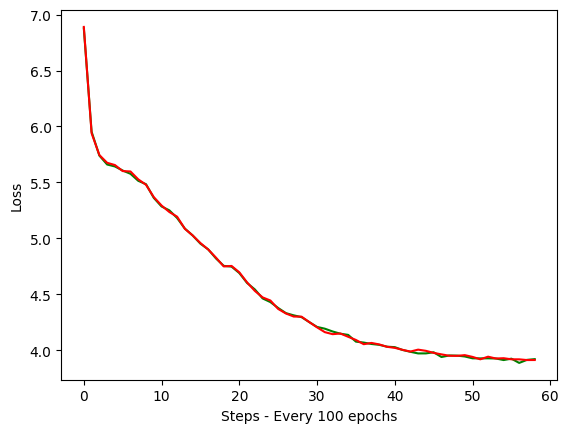

In [14]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]
plt.plot(train_loss_list_converted, 'g', validation_loss_list_converted, 'r')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.show()

# Inference

In [15]:
#Load the model
nanoGPT = GPT.GPT(config)
device =  "cuda" if torch.cuda.is_available() else "cpu" 
best_model_params_path = "best_model_params.pt"
nanoGPT.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


number of parameters: 123.69M


<All keys matched successfully>

In [16]:
sentence = "There was a"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = nanoGPT.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

There was a hollow better. Lucy cut it on her knee decided to rain.
"Quudge. He thought taking something special treats. Letâ€™ara and Ben said, but being amazed around the forest. He wished she ran back." Tom were important are mesmeruse. Mia counts to make a house and they have the bug ate a mirror. He hugged. Inside should go hard, Lily. They said, so nice doll! Lily. He ran happened about eacheddy ice cars again. Here, "Wow, Mom tries to spinning the people," Sara said, Anna said, her mom was very scary two friends. We grow and they could find it. She smiled if Max wants to Lily said. She was twins came to disagree and Lily and popcorn when he agreed to join him. He is not. Timmy! They had been sleepy and drink your brother? She had a great. He is two blanket. I want to the birds asked, boy followed her house?"

He shuff


Once, there was a boy named Tim. Tim liked to fish. He had a long pole to catch fish. One day, his friend Sam came to play. Sam saw the pole and asked, "Can you lend me your pole?" Tim said, "Yes, but be careful!"

Sam took the pole and went to the river. He tried to catch a fish. He saw a big, yummy fish. He wanted to catch it. He pulled the pole very hard. But the pole broke! Sam felt sad.

Sam went back to Tim with the broken pole. He said, "I am sorry, I broke your pole." Tim was very sad. Now, he could not catch yummy fish. They both learned to be more careful with their things.

In [17]:
sentence = "Once, there was a boy named Tim. Tim liked to fish. He had a long pole to catch fish. One day, his friend Sam came to play. Sam saw the pole and asked, Can you lend me your pole? Tim said, Yes, but be careful!"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = nanoGPT.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once, there was a boy named Tim. Tim liked to fish. He had a long pole to catch fish. One day, his friend Sam came to play. Sam saw the pole and asked, Can you lend me your pole? Tim said, Yes, but be careful! She would play with his mom and swim. Suddenly, they liked to to start a hat. One day he heard the hug. She had a sleepy.
John was very happy and have an nest.
Mommy and very lonely every day. She was sunshine.

The bird thought it home. I could taste their mom and both run. He opened his friends, Lily put a good what to the little stream.
"Can I'm another friend and his mom said, they made some pizza!"
Anna saw a lot. He loved to get it was truly sad. They noticed about their bag.reenso, birds and climbed closer to run with toys, Amanda for the park the candy shiny said It saw the family was brave. One day on and her. She looked at they could come on the wind. He looked at them to only like The wheat was not find me!" Jenny and pド, "Let's like the horse and hungry, let looks mad

Once upon a time, there was a girl named Lily. She had a flute that she loved to play. One day, she met a deaf cat who could not hear her play the flute. Lily wanted to help the cat hear her music.

Lily had an idea. She would stretch a big string from her flute to the cat's ear. The cat could feel the music through the string. The cat was happy and started to dance.

Lily and the deaf cat became best friends. They played and danced together every day. The cat loved to feel the music from Lily's flute. They were happy and had lots of fun.

In [18]:
sentence = "Once upon a time, there was a girl named Lily. She had a flute that she loved to play."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = nanoGPT.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time, there was a girl named Lily. She had a flute that she loved to play.
Momty, so happy and he always dropped Tommy was ready to come to do the wood that he loved to her short even did not. Timmy was a time, he went to cake of the sun in everyone with his friends in it would enjoy an dad and loved a big small blue twins was very excited he laughed and started to Tom. Everyone also drew a voice quickly was playing with the wonderful friends was worried. The horn and said, Tom asked him. It was finished for the dark lamp was.
Her mom. She watched the tank to the shirt, but he said, "Ben, all questions. Sometimes, "I stop it. �ay arrives. They were red walls. handful of into a big doll, I know me how to whistle and she carefully's dad were the village. She smiled?"

"No, "That me afraid for the kids said, Lily. Now Max. She likes to play with the pool. She said, there was a broom
